# 03 – Temporal Analysis: 2015 vs 2025

**Global Cargo Shipping Network (GCSN)**

This notebook compares the network structure across the two time periods to identify how the global cargo shipping network evolved over a decade.

The 10-year gap (2015→2025) spans several major disruptions:
- COVID-19 pandemic (2020–2021): massive supply chain disruption
- Suez Canal blockage (March 2021): Ever Given incident
- Russia-Ukraine war (2022): Black Sea / Baltic rerouting
- Red Sea / Houthi crisis (2023–2025): Cape of Good Hope rerouting
- Expansion of China's Belt & Road Initiative ports

### Analyses performed
1. Side-by-side summary comparison table (all key metrics)
2. Degree distribution comparison + KS test
3. Strength distribution comparison + KS test
4. Link weight distribution comparison + KS test
5. Node/edge Jaccard overlap (network persistence)
6. Persistent vs new vs lost edges (route evolution)
7. Top ports that gained / lost importance
8. Clustering and structural changes
9. Key findings summary


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from scipy import stats

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
})

FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True)

COLORS = {'2015': 'steelblue', '2025': 'darkorange'}

print('Imports OK. NetworkX', nx.__version__)


Imports OK. NetworkX 3.4.2


## 1. Load Data and Build All Graphs


In [2]:
df_2015 = pd.read_csv('../EdgeList/shipping_network_2015.csv')
df_2025 = pd.read_csv('../EdgeList/shipping_network_2025.csv')


def build_all_graphs(df):
    """Build directed + undirected, weighted + unweighted graphs."""
    # Directed unweighted
    Gd = nx.DiGraph()
    Gd.add_edges_from(zip(df['source'], df['target']))

    # Undirected unweighted
    Gu = nx.Graph()
    Gu.add_edges_from(zip(df['source'], df['target']))

    # Directed weighted
    Gd_w = nx.from_pandas_edgelist(
        df, 'source', 'target', edge_attr='weight',
        create_using=nx.DiGraph())

    # Undirected weighted
    Gu_w = nx.Graph()
    for _, row in df.iterrows():
        u, v, w = row['source'], row['target'], row['weight']
        if Gu_w.has_edge(u, v):
            Gu_w[u][v]['weight'] += w
        else:
            Gu_w.add_edge(u, v, weight=w)

    return Gd, Gu, Gd_w, Gu_w


print('Building graphs for 2015...')
Gd_2015, Gu_2015, Gd_w_2015, Gu_w_2015 = build_all_graphs(df_2015)
print('  Done.')

print('Building graphs for 2025...')
Gd_2025, Gu_2025, Gd_w_2025, Gu_w_2025 = build_all_graphs(df_2025)
print('  Done.')


def gcc(Gu):
    return Gu.subgraph(max(nx.connected_components(Gu), key=len)).copy()


gcc_2015 = gcc(Gu_2015)
gcc_2025 = gcc(Gu_2025)

for year, Gd, Gu, Gd_w, Gu_w, gcc_g in [
    ('2015', Gd_2015, Gu_2015, Gd_w_2015, Gu_w_2015, gcc_2015),
    ('2025', Gd_2025, Gu_2025, Gd_w_2025, Gu_w_2025, gcc_2025)
]:
    w_arr = np.array([d['weight'] for _, _, d in Gd_w.edges(data=True)])
    print(f'  {year}: N={Gd.number_of_nodes():,}, E_d={Gd.number_of_edges():,},'
          f' E_u={Gu.number_of_edges():,}, total_voyages={w_arr.sum():,},'
          f' GCC_frac={gcc_g.number_of_nodes()/Gu.number_of_nodes()*100:.1f}%')


Building graphs for 2015...
  Done.
Building graphs for 2025...
  Done.
  2015: N=7,097, E_d=188,545, E_u=145,745, total_voyages=1,791,795, GCC_frac=99.8%
  2025: N=7,717, E_d=182,300, E_u=139,499, total_voyages=1,965,325, GCC_frac=99.6%


## Helper Functions


In [3]:
def log_binning(data, n_bins=35):
    data = np.asarray(data, dtype=float)
    data = data[data > 0]
    if len(data) < 2:
        return np.array([]), np.array([])
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), n_bins + 1)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centres = np.sqrt(edges[:-1] * edges[1:])
    mask = hist > 0
    return centres[mask], hist[mask]


def mle_powerlaw(data, x_min=1):
    data = np.asarray(data, dtype=float)
    data = data[data >= x_min]
    n = len(data)
    if n == 0:
        return np.nan
    return 1.0 + n / np.sum(np.log(data / (x_min - 0.5)))


def sample_apl(G, n=300, seed=42):
    rng = np.random.default_rng(seed)
    nodes = np.array(list(G.nodes()))
    sample = rng.choice(nodes, size=min(n, len(nodes)), replace=False)
    all_d = []
    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        all_d.extend(v for v in lengths.values() if v > 0)
    return float(np.mean(all_d))


print('Helper functions defined.')


Helper functions defined.


## 2. Full Metrics Comparison Table


In [4]:
print('Computing all metrics — this may take a few minutes...')

metrics = {}

for year, Gd, Gu, Gd_w, Gu_w, gcc_g in [
    ('2015', Gd_2015, Gu_2015, Gd_w_2015, Gu_w_2015, gcc_2015),
    ('2025', Gd_2025, Gu_2025, Gd_w_2025, Gu_w_2025, gcc_2025)
]:
    deg_arr      = np.array([d for _, d in Gu.degree()])
    in_deg_arr   = np.array([d for _, d in Gd.in_degree()])
    out_deg_arr  = np.array([d for _, d in Gd.out_degree()])
    w_arr        = np.array([d['weight'] for _, _, d in Gd_w.edges(data=True)])
    strength_arr = np.array([d for _, d in Gu_w.degree(weight='weight')])

    C_unw = nx.average_clustering(Gu)
    C_w   = nx.average_clustering(Gu_w, weight='weight')

    try:
        assort_r = nx.degree_assortativity_coefficient(Gu)
    except Exception:
        assort_r = np.nan

    mu_deg  = mle_powerlaw(deg_arr, x_min=1)
    mu_w    = mle_powerlaw(w_arr,   x_min=1)
    eta_s   = mle_powerlaw(strength_arr, x_min=1)

    print(f'  Computing APL for {year} (sampled)...')
    apl = sample_apl(gcc_g, n=300)
    print(f'    L = {apl:.4f}')

    # Strength-degree alpha
    deg_dict = dict(Gu_w.degree())
    str_dict = dict(Gu_w.degree(weight='weight'))
    k_all = np.array([deg_dict[n] for n in Gu_w.nodes() if deg_dict[n] > 0])
    s_all = np.array([str_dict[n] for n in Gu_w.nodes() if deg_dict[n] > 0])
    if len(k_all) > 3 and k_all.max() > k_all.min():
        alpha_val, _, _, _, _ = stats.linregress(np.log10(k_all), np.log10(s_all))
    else:
        alpha_val = np.nan

    metrics[year] = {
        'N': Gu.number_of_nodes(),
        'E_directed': Gd.number_of_edges(),
        'E_undirected': Gu.number_of_edges(),
        'density_d': nx.density(Gd),
        'density_u': nx.density(Gu),
        'mean_k': float(deg_arr.mean()),
        'max_k': int(deg_arr.max()),
        'mean_in': float(in_deg_arr.mean()),
        'mean_out': float(out_deg_arr.mean()),
        'C_unw': C_unw,
        'C_w': C_w,
        'apl': apl,
        'assort_r': assort_r,
        'mu_deg': mu_deg,
        'total_voyages': int(w_arr.sum()),
        'mean_J': float(w_arr.mean()),
        'max_w': int(w_arr.max()),
        'mean_s': float(strength_arr.mean()),
        'mu_w': mu_w,
        'eta_s': eta_s,
        'alpha': alpha_val,
        'n_comps': nx.number_connected_components(Gu),
        'gcc_frac': gcc_g.number_of_nodes() / Gu.number_of_nodes(),
        'scc': nx.number_strongly_connected_components(Gd),
        'wcc': nx.number_weakly_connected_components(Gd),
    }

m15, m25 = metrics['2015'], metrics['2025']


def pct_change(a, b):
    """Percentage change from a to b."""
    if a == 0:
        return 'N/A'
    return f'{(b - a) / abs(a) * 100:+.1f}%'


rows = [
    ('TOPOLOGY', '', '', ''),
    ('Nodes N',                          f'{m15["N"]:,}',             f'{m25["N"]:,}',             pct_change(m15['N'],           m25['N'])),
    ('Directed edges',                   f'{m15["E_directed"]:,}',    f'{m25["E_directed"]:,}',    pct_change(m15['E_directed'],  m25['E_directed'])),
    ('Undirected edges',                 f'{m15["E_undirected"]:,}',  f'{m25["E_undirected"]:,}',  pct_change(m15['E_undirected'],m25['E_undirected'])),
    ('Density (directed)',               f'{m15["density_d"]:.6f}',   f'{m25["density_d"]:.6f}',   pct_change(m15['density_d'],   m25['density_d'])),
    ('Connected components',             f'{m15["n_comps"]}',         f'{m25["n_comps"]}',         pct_change(m15['n_comps'],     m25['n_comps'])),
    ('SCCs (directed)',                  f'{m15["scc"]}',             f'{m25["scc"]}',             pct_change(m15['scc'],         m25['scc'])),
    ('GCC fraction of N',               f'{m15["gcc_frac"]*100:.1f}%', f'{m25["gcc_frac"]*100:.1f}%', ''),
    ('DEGREE', '', '', ''),
    ('Mean undirected degree <k>',       f'{m15["mean_k"]:.2f}',      f'{m25["mean_k"]:.2f}',      pct_change(m15['mean_k'],      m25['mean_k'])),
    ('Mean in-degree',                   f'{m15["mean_in"]:.2f}',     f'{m25["mean_in"]:.2f}',     pct_change(m15['mean_in'],     m25['mean_in'])),
    ('Max undirected degree',            f'{m15["max_k"]:,}',         f'{m25["max_k"]:,}',         pct_change(m15['max_k'],       m25['max_k'])),
    ('Degree power-law exponent mu',     f'{m15["mu_deg"]:.3f}',      f'{m25["mu_deg"]:.3f}',      ''),
    ('CLUSTERING & PATH LENGTH', '', '', ''),
    ('Clustering C (unweighted)',        f'{m15["C_unw"]:.4f}',       f'{m25["C_unw"]:.4f}',       pct_change(m15['C_unw'],       m25['C_unw'])),
    ('Clustering C (weighted)',          f'{m15["C_w"]:.4f}',         f'{m25["C_w"]:.4f}',         pct_change(m15['C_w'],         m25['C_w'])),
    ('Avg path length L (sampled GCC)', f'{m15["apl"]:.4f}',         f'{m25["apl"]:.4f}',         pct_change(m15['apl'],         m25['apl'])),
    ('Assortativity r',                  f'{m15["assort_r"]:.4f}',    f'{m25["assort_r"]:.4f}',    pct_change(m15['assort_r'],    m25['assort_r'])),
    ('WEIGHTS & TRAFFIC', '', '', ''),
    ('Total voyages',                    f'{m15["total_voyages"]:,}',  f'{m25["total_voyages"]:,}',  pct_change(m15['total_voyages'], m25['total_voyages'])),
    ('Mean journeys per link <J>',       f'{m15["mean_J"]:.2f}',      f'{m25["mean_J"]:.2f}',      pct_change(m15['mean_J'],      m25['mean_J'])),
    ('Max link weight',                  f'{m15["max_w"]:,}',         f'{m25["max_w"]:,}',         pct_change(m15['max_w'],       m25['max_w'])),
    ('Mean node strength <s>',           f'{m15["mean_s"]:.1f}',      f'{m25["mean_s"]:.1f}',      pct_change(m15['mean_s'],      m25['mean_s'])),
    ('Link weight exponent mu_w',        f'{m15["mu_w"]:.3f}',        f'{m25["mu_w"]:.3f}',        ''),
    ('Strength exponent eta',            f'{m15["eta_s"]:.3f}',       f'{m25["eta_s"]:.3f}',       ''),
    ('Strength-degree scaling alpha',    f'{m15["alpha"]:.3f}',       f'{m25["alpha"]:.3f}',       ''),
]

df_cmp = pd.DataFrame(rows, columns=['Metric', '2015', '2025', 'Change'])

print()
print('=' * 75)
print('  GCSN — 2015 vs 2025 FULL COMPARISON')
print('=' * 75)
print(df_cmp.to_string(index=False))
print('=' * 75)

df_cmp.to_csv('../Figures/03_comparison_table.csv', index=False)
print('\nTable saved to ../Figures/03_comparison_table.csv')


Computing all metrics — this may take a few minutes...
  Computing APL for 2015 (sampled)...
    L = 3.2889
  Computing APL for 2025 (sampled)...
    L = 3.5765

  GCSN — 2015 vs 2025 FULL COMPARISON
                         Metric      2015      2025 Change
                       TOPOLOGY                           
                        Nodes N     7,097     7,717  +8.7%
                 Directed edges   188,545   182,300  -3.3%
               Undirected edges   145,745   139,499  -4.3%
             Density (directed)  0.003744  0.003062 -18.2%
           Connected components         8         5 -37.5%
                SCCs (directed)       219       203  -7.3%
              GCC fraction of N     99.8%     99.6%       
                         DEGREE                           
     Mean undirected degree <k>     41.07     36.15 -12.0%
                 Mean in-degree     26.57     23.62 -11.1%
          Max undirected degree     1,233     1,171  -5.0%
   Degree power-law exponent mu  

## 3. Distribution Comparisons with KS Tests

The **Kolmogorov-Smirnov (KS) test** compares two empirical distributions.  
A small p-value (< 0.05) means the distributions are statistically different.


KS Test Results
Distribution                 KS stat      p-value   Significant?
---------------------------------------------------------------
Degree P(k)                   0.0286   4.6116e-03            YES
Strength P(s)                 0.0181   1.7269e-01             no
Link weight P(w)              0.0256   2.1996e-53            YES


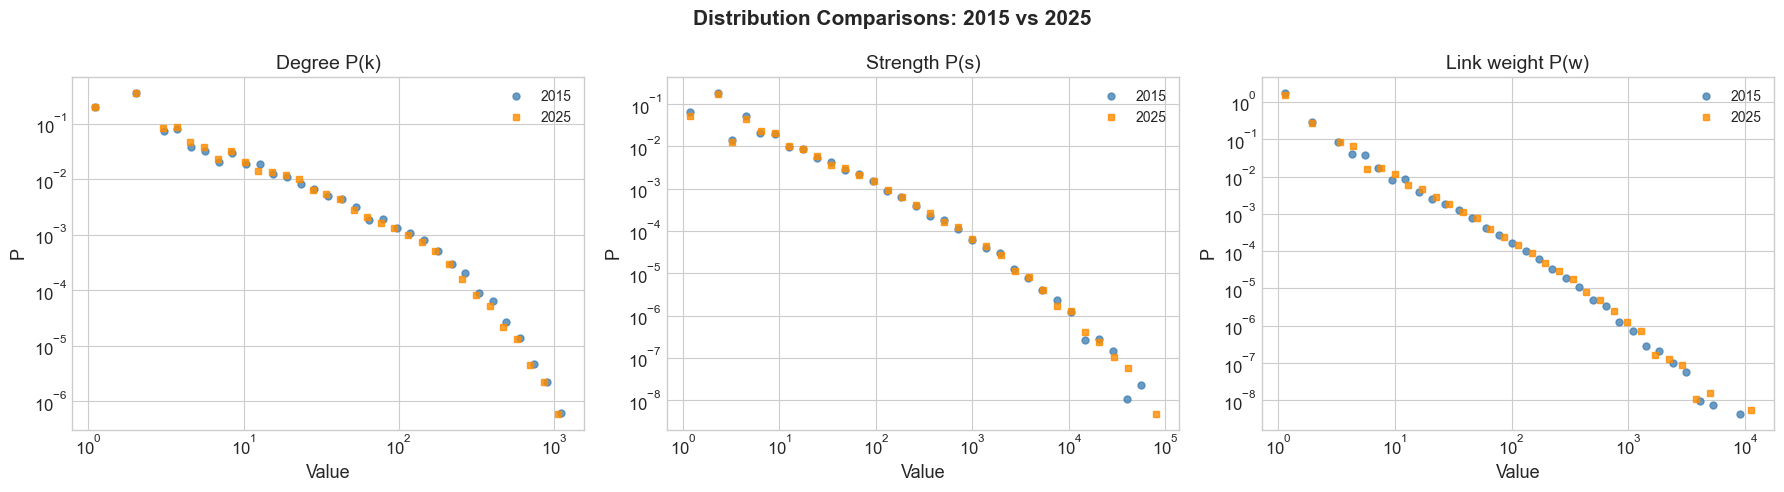

In [5]:
deg_2015 = np.array([d for _, d in Gu_2015.degree()])
deg_2025 = np.array([d for _, d in Gu_2025.degree()])

str_2015 = np.array([d for _, d in Gu_w_2015.degree(weight='weight')])
str_2025 = np.array([d for _, d in Gu_w_2025.degree(weight='weight')])

w_2015 = np.array([d['weight'] for _, _, d in Gd_w_2015.edges(data=True)])
w_2025 = np.array([d['weight'] for _, _, d in Gd_w_2025.edges(data=True)])

ks_deg = stats.ks_2samp(deg_2015, deg_2025)
ks_str = stats.ks_2samp(str_2015, str_2025)
ks_w   = stats.ks_2samp(w_2015,   w_2025)

print('KS Test Results')
print(f'{"Distribution":<25} {"KS stat":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 63)
for name, ks in [('Degree P(k)', ks_deg), ('Strength P(s)', ks_str), ('Link weight P(w)', ks_w)]:
    sig = 'YES' if ks.pvalue < 0.05 else 'no'
    print(f'{name:<25} {ks.statistic:>10.4f} {ks.pvalue:>12.4e} {sig:>14}')


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution Comparisons: 2015 vs 2025', fontsize=15, fontweight='bold')

for ax, (name, d15, d25) in zip(axes, [
    ('Degree P(k)',         deg_2015, deg_2025),
    ('Strength P(s)',       str_2015, str_2025),
    ('Link weight P(w)',    w_2015,   w_2025),
]):
    x15, p15 = log_binning(d15)
    x25, p25 = log_binning(d25)
    ax.loglog(x15, p15, 'o', ms=5, alpha=0.8, color=COLORS['2015'], label='2015')
    ax.loglog(x25, p25, 's', ms=5, alpha=0.8, color=COLORS['2025'], label='2025')
    ax.set_xlabel('Value')
    ax.set_ylabel('P')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR + '03_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Network Overlap: Jaccard Similarity

Jaccard index = |A ∩ B| / |A ∪ B|  
Measures what fraction of nodes/edges are shared between the two years.

- J ≈ 1 → nearly identical networks
- J ≈ 0 → completely different


In [6]:
nodes_15 = set(Gu_2015.nodes())
nodes_25 = set(Gu_2025.nodes())

edges_15_d = set(Gd_2015.edges())
edges_25_d = set(Gd_2025.edges())
edges_15_u = set(Gu_2015.edges())
edges_25_u = set(Gu_2025.edges())

# Jaccard
J_nodes   = len(nodes_15 & nodes_25) / len(nodes_15 | nodes_25)
J_edges_d = len(edges_15_d & edges_25_d) / len(edges_15_d | edges_25_d)
J_edges_u = len(edges_15_u & edges_25_u) / len(edges_15_u | edges_25_u)

# Sets
nodes_new    = nodes_25 - nodes_15
nodes_lost   = nodes_15 - nodes_25
nodes_common = nodes_15 & nodes_25

edges_new_d    = edges_25_d - edges_15_d
edges_lost_d   = edges_15_d - edges_25_d
edges_common_d = edges_15_d & edges_25_d

print(f'\n{"="*65}')
print(f'  NETWORK OVERLAP: 2015 vs 2025')
print(f'{"="*65}')
print(f'  NODES')
print(f'    2015 nodes       : {len(nodes_15):>8,}')
print(f'    2025 nodes       : {len(nodes_25):>8,}')
print(f'    Common (both)    : {len(nodes_common):>8,}')
print(f'    New in 2025      : {len(nodes_new):>8,}')
print(f'    Lost from 2015   : {len(nodes_lost):>8,}')
print(f'    Jaccard (nodes)  : {J_nodes:>8.4f}')
print(f'  DIRECTED EDGES')
print(f'    2015 edges       : {len(edges_15_d):>8,}')
print(f'    2025 edges       : {len(edges_25_d):>8,}')
print(f'    Common (both)    : {len(edges_common_d):>8,}')
print(f'    New in 2025      : {len(edges_new_d):>8,}')
print(f'    Lost from 2015   : {len(edges_lost_d):>8,}')
print(f'    Jaccard (d-edges): {J_edges_d:>8.4f}')
print(f'  UNDIRECTED EDGES')
print(f'    Jaccard (u-edges): {J_edges_u:>8.4f}')
print(f'{"="*65}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Network Overlap: 2015 vs 2025', fontsize=14, fontweight='bold')

# Nodes pie
axes[0].pie(
    [len(nodes_common), len(nodes_new), len(nodes_lost)],
    labels=[
        f'Shared\n{len(nodes_common):,}',
        f'New 2025\n{len(nodes_new):,}',
        f'Lost\n{len(nodes_lost):,}'
    ],
    autopct='%1.1f%%',
    colors=['#3498db', '#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title(f'Ports (Jaccard = {J_nodes:.4f})')

# Edges pie
axes[1].pie(
    [len(edges_common_d), len(edges_new_d), len(edges_lost_d)],
    labels=[
        f'Shared\n{len(edges_common_d):,}',
        f'New 2025\n{len(edges_new_d):,}',
        f'Lost\n{len(edges_lost_d):,}'
    ],
    autopct='%1.1f%%',
    colors=['#3498db', '#2ecc71', '#e74c3c'],
    startangle=90
)
axes[1].set_title(f'Directed Routes (Jaccard = {J_edges_d:.4f})')

plt.tight_layout()
plt.savefig(FIG_DIR + '03_overlap.png', dpi=150, bbox_inches='tight')
plt.show()


MemoryError: 

## 5. Route Weight Changes: Persistent Routes

For routes present in **both** 2015 and 2025, we examine how traffic volume changed.


In [ ]:
# Build weight dicts for directed graphs
w_dict_2015 = {(r['source'], r['target']): r['weight'] for _, r in df_2015.iterrows()}
w_dict_2025 = {(r['source'], r['target']): r['weight'] for _, r in df_2025.iterrows()}

# Persistent routes (in both years)
common_routes = edges_15_d & edges_25_d

delta_rows = []
for (u, v) in common_routes:
    w15 = w_dict_2015.get((u, v), 0)
    w25 = w_dict_2025.get((u, v), 0)
    delta = w25 - w15
    pct   = (w25 - w15) / max(w15, 1) * 100
    delta_rows.append({'source': u, 'target': v,
                       'w_2015': w15, 'w_2025': w25,
                       'delta': delta, 'pct_change': pct})

df_delta = pd.DataFrame(delta_rows).sort_values('delta', ascending=False)

print(f'Persistent routes (present both years): {len(df_delta):,}')
print(f'Routes with increased traffic: {(df_delta["delta"] > 0).sum():,}')
print(f'Routes with decreased traffic: {(df_delta["delta"] < 0).sum():,}')
print(f'Unchanged routes: {(df_delta["delta"] == 0).sum():,}')

# Top gainers
top_n = 15
df_gainers = df_delta.nlargest(top_n, 'delta')
df_losers  = df_delta.nsmallest(top_n, 'delta')

df_gainers['route'] = df_gainers['source'] + ' -> ' + df_gainers['target']
df_losers['route']  = df_losers['source']  + ' -> ' + df_losers['target']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Route Traffic Change 2015 -> 2025 (Persistent Routes)', fontsize=14, fontweight='bold')

axes[0].barh(df_gainers['route'][::-1], df_gainers['delta'][::-1],
             color='#2ecc71', edgecolor='none')
axes[0].set_xlabel('Delta voyages (2025 - 2015)')
axes[0].set_title(f'Top {top_n} Routes with Most Growth')

axes[1].barh(df_losers['route'][::-1], df_losers['delta'][::-1],
             color='#e74c3c', edgecolor='none')
axes[1].set_xlabel('Delta voyages (2025 - 2015)')
axes[1].set_title(f'Top {top_n} Routes with Most Decline')

plt.tight_layout()
plt.savefig(FIG_DIR + '03_route_changes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 15 routes with most growth:')
print(df_gainers[['route', 'w_2015', 'w_2025', 'delta', 'pct_change']].to_string(index=False))
print('\nTop 15 routes with most decline:')
print(df_losers[['route', 'w_2015', 'w_2025', 'delta', 'pct_change']].to_string(index=False))


## 6. Port Importance Evolution

Ports that rose and fell in **strength** (traffic) between 2015 and 2025.


In [ ]:
s_2015 = dict(Gu_w_2015.degree(weight='weight'))
s_2025 = dict(Gu_w_2025.degree(weight='weight'))
k_2015 = dict(Gu_2015.degree())
k_2025 = dict(Gu_2025.degree())

common_ports = set(s_2015.keys()) & set(s_2025.keys())

port_rows = []
for port in common_ports:
    s15 = s_2015[port]
    s25 = s_2025[port]
    k15 = k_2015[port]
    k25 = k_2025[port]
    port_rows.append({
        'port': port,
        's_2015': s15, 's_2025': s25,
        's_delta': s25 - s15,
        's_pct': (s25 - s15) / max(s15, 1) * 100,
        'k_2015': k15, 'k_2025': k25,
        'k_delta': k25 - k15,
    })

df_ports = pd.DataFrame(port_rows)

# Top risers and fallers by strength
top_n = 20
top_risers  = df_ports.nlargest(top_n,  's_delta')
top_fallers = df_ports.nsmallest(top_n, 's_delta')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Port Strength Change 2015 -> 2025 (Persistent Ports)', fontsize=14, fontweight='bold')

axes[0].barh(top_risers['port'][::-1], top_risers['s_delta'][::-1],
             color='#2ecc71', edgecolor='none')
axes[0].set_xlabel('Strength change (voyages/year)')
axes[0].set_title(f'Top {top_n} Rising Ports (most traffic gain)')

axes[1].barh(top_fallers['port'][::-1], top_fallers['s_delta'][::-1],
             color='#e74c3c', edgecolor='none')
axes[1].set_xlabel('Strength change (voyages/year)')
axes[1].set_title(f'Top {top_n} Declining Ports (most traffic loss)')

plt.tight_layout()
plt.savefig(FIG_DIR + '03_port_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 ports with most strength growth:')
print(top_risers[['port', 's_2015', 's_2025', 's_delta', 's_pct', 'k_delta']].to_string(index=False))
print('\nTop 20 ports with most strength decline:')
print(top_fallers[['port', 's_2015', 's_2025', 's_delta', 's_pct', 'k_delta']].to_string(index=False))


## 7. Hub Stability: Rank Correlation of Top Ports

Do the same ports dominate both years? We compute Spearman rank correlation of port degrees across both years.


In [ ]:
common_ports_list = sorted(common_ports)

k15_vec = np.array([k_2015[p] for p in common_ports_list])
k25_vec = np.array([k_2025[p] for p in common_ports_list])
s15_vec = np.array([s_2015[p] for p in common_ports_list])
s25_vec = np.array([s_2025[p] for p in common_ports_list])

rho_k, pval_k = stats.spearmanr(k15_vec, k25_vec)
rho_s, pval_s = stats.spearmanr(s15_vec, s25_vec)

print(f'Spearman rank correlation (degree):   rho = {rho_k:.4f}  (p = {pval_k:.2e})')
print(f'Spearman rank correlation (strength):  rho = {rho_s:.4f}  (p = {pval_s:.2e})')
print()
print('rho close to 1 -> same ports dominate in both years (stable hub structure).')
print('rho close to 0 -> port rankings reshuffled significantly.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Port Rank Stability: 2015 vs 2025', fontsize=14, fontweight='bold')

for ax, (v15, v25, label, rho, pval) in zip(axes, [
    (k15_vec, k25_vec, 'Degree', rho_k, pval_k),
    (s15_vec, s25_vec, 'Strength', rho_s, pval_s),
]):
    ax.scatter(v15, v25, alpha=0.15, s=8, color='steelblue')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(f'Port {label} 2015')
    ax.set_ylabel(f'Port {label} 2025')
    ax.set_title(f'{label}  (Spearman rho = {rho:.4f})')
    # y=x reference
    mn = min(v15.min(), v25.min())
    mx = max(v15.max(), v25.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='y=x (no change)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + '03_hub_stability.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Structural Change: Weight Distribution Shift

Plot the full degree and weight distributions side-by-side with CCDF to visually assess structural shifts.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Structural Comparison: 2015 vs 2025', fontsize=16, fontweight='bold')

def ccdf(data):
    x = np.sort(data)
    y = 1 - np.arange(1, len(x)+1) / len(x)
    return x, y

datasets = [
    ('Degree P(k)',    deg_2015, deg_2025),
    ('Strength P(s)',  str_2015, str_2025),
    ('Link weight P(w)', w_2015, w_2025),
]

for col, (name, d15, d25) in enumerate(datasets):
    # PDF (log-binned)
    ax = axes[0, col]
    x15, p15 = log_binning(d15)
    x25, p25 = log_binning(d25)
    if len(x15): ax.loglog(x15, p15, 'o-', ms=4, lw=1.2, color=COLORS['2015'], label='2015')
    if len(x25): ax.loglog(x25, p25, 's-', ms=4, lw=1.2, color=COLORS['2025'], label='2025')
    ax.set_xlabel('Value')
    ax.set_ylabel('P')
    ax.set_title(f'{name} — PDF')
    ax.legend()

    # CCDF
    ax2 = axes[1, col]
    xc15, yc15 = ccdf(d15)
    xc25, yc25 = ccdf(d25)
    ax2.loglog(xc15, yc15 + 1e-10, '-', lw=2, color=COLORS['2015'], label='2015')
    ax2.loglog(xc25, yc25 + 1e-10, '-', lw=2, color=COLORS['2025'], label='2025')
    ax2.set_xlabel('Value')
    ax2.set_ylabel('P(X > x)')
    ax2.set_title(f'{name} — CCDF')
    ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR + '03_structural_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Key Findings Summary


In [ ]:
print()
print('=' * 72)
print('  GCSN TEMPORAL ANALYSIS — KEY FINDINGS (2015 -> 2025)')
print('=' * 72)

# Node/Edge change
dn = m25['N'] - m15['N']
de = m25['E_directed'] - m15['E_directed']
print(f'\n  1. NETWORK SIZE')
print(f'     Ports (nodes):    {m15["N"]:>6,} -> {m25["N"]:>6,}  ({dn:+,}, {dn/m15["N"]*100:+.1f}%)')
print(f'     Routes (d-edges): {m15["E_directed"]:>6,} -> {m25["E_directed"]:>6,}  ({de:+,}, {de/m15["E_directed"]*100:+.1f}%)')
print(f'     Route overlap (Jaccard): {J_edges_d:.4f}')
print(f'     {len(edges_new_d):,} new routes appeared; {len(edges_lost_d):,} routes disappeared.')

print(f'\n  2. CONNECTIVITY & SMALL-WORLD')
print(f'     Mean degree <k>: {m15["mean_k"]:.2f} -> {m25["mean_k"]:.2f}')
print(f'     Clustering C:    {m15["C_unw"]:.4f} -> {m25["C_unw"]:.4f}')
print(f'     Path length L:   {m15["apl"]:.4f} -> {m25["apl"]:.4f}')

print(f'\n  3. TRAFFIC VOLUME')
print(f'     Total voyages:   {m15["total_voyages"]:,} -> {m25["total_voyages"]:,}')
print(f'     Mean J per link: {m15["mean_J"]:.2f} -> {m25["mean_J"]:.2f}')

print(f'\n  4. POWER-LAW EXPONENTS')
print(f'     Degree mu:    {m15["mu_deg"]:.3f} -> {m25["mu_deg"]:.3f}')
print(f'     Strength eta: {m15["eta_s"]:.3f} -> {m25["eta_s"]:.3f}')
print(f'     Weight mu_w:  {m15["mu_w"]:.3f} -> {m25["mu_w"]:.3f}')
print(f'     Scaling alpha (s~k^a): {m15["alpha"]:.3f} -> {m25["alpha"]:.3f}')

print(f'\n  5. HUB STABILITY')
print(f'     Spearman rho (degree):   {rho_k:.4f}')
print(f'     Spearman rho (strength): {rho_s:.4f}')
print(f'     => Hub structure is {"STABLE" if rho_k > 0.7 else "MODERATELY STABLE" if rho_k > 0.4 else "RESHUFFLED"}')

print(f'\n  6. KS TESTS (2015 vs 2025 distributions)')
print(f'     Degree:   KS={ks_deg.statistic:.4f}  p={ks_deg.pvalue:.3e}  {"DIFFERENT" if ks_deg.pvalue<0.05 else "similar"}')
print(f'     Strength: KS={ks_str.statistic:.4f}  p={ks_str.pvalue:.3e}  {"DIFFERENT" if ks_str.pvalue<0.05 else "similar"}')
print(f'     Weight:   KS={ks_w.statistic:.4f}  p={ks_w.pvalue:.3e}  {"DIFFERENT" if ks_w.pvalue<0.05 else "similar"}')

print()
print('=' * 72)

# Save summary
df_cmp.to_csv('../Figures/03_comparison_table.csv', index=False)
print('Full comparison table saved to ../Figures/03_comparison_table.csv')
